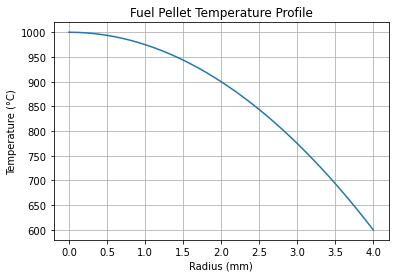

In [20]:
import numpy as np
import matplotlib.pyplot as plt

#Plot the temperature profile on the pellet

R = 0.004      # m
Ts = 600       # °C
k = 3          # W/m-K
q = 3e8        # W/m³

r = np.linspace(0, R, 200)

T = Ts + q/(4*k)*(R**2 - r**2)

plt.plot(r*1000, T)

plt.xlabel("Radius (mm)")
plt.ylabel("Temperature (°C)")
plt.title("Fuel Pellet Temperature Profile")
plt.savefig("temperature_profile.png", dpi=300, bbox_inches="tight")
plt.grid()
plt.show()

In [2]:
#Calculate the centerline temperature 

T_center = Ts + q*R**2/(4*k)

print(f"Centerline Temperature = {T_center:.1f} °C")

Centerline Temperature = 1000.0 °C


q'''=1.0e+08 W/m³  |  T_center=666.7 °C
q'''=2.0e+08 W/m³  |  T_center=733.3 °C
q'''=3.0e+08 W/m³  |  T_center=800.0 °C
q'''=4.0e+08 W/m³  |  T_center=866.7 °C
q'''=5.0e+08 W/m³  |  T_center=933.3 °C


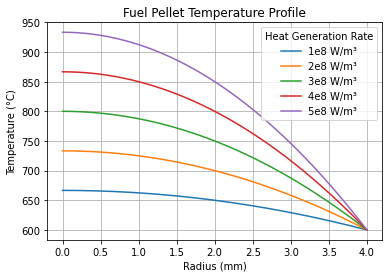

In [7]:
#T profile vs Heat Generation rates

powers = [1e8, 2e8, 3e8, 4e8, 5e8]

for q in powers:

    T = Ts + q/(4*k)*(R**2 - r**2)

    plt.plot(
        r*1000,
        T,
        label=f"{q/1e8:.0f}e8 W/m³"
    )

    T_center = Ts + q*R**2/(4*k)

    print(
        f"q'''={q:.1e} W/m³  |  "
        f"T_center={T_center:.1f} °C"
    )

plt.xlabel("Radius (mm)")
plt.ylabel("Temperature (°C)")
plt.title("Fuel Pellet Temperature Profile")
plt.legend(title="Heat Generation Rate")
plt.grid(True)
plt.savefig("power_comparison.png",dpi=300,bbox_inches="tight")
plt.show()

k = 2 W/m-K  ->  T_center = 1200.0 °C
k = 3 W/m-K  ->  T_center = 1000.0 °C
k = 4 W/m-K  ->  T_center = 900.0 °C
k = 6 W/m-K  ->  T_center = 800.0 °C
k = 8 W/m-K  ->  T_center = 750.0 °C


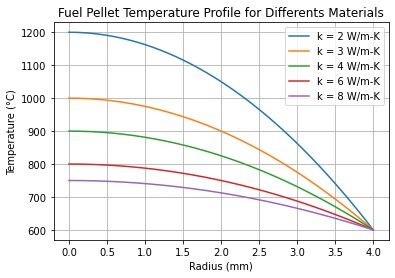

In [19]:
#T profile for differents conductivities

q = 3e8        # W/m³
mat = [2, 3, 4, 6, 8] # W/m-K

for k in mat:

    T = Ts + q/(4*k)*(R**2 - r**2)

    T_center = Ts + q*R**2/(4*k)

    print(
        f"k = {k} W/m-K  ->  "
        f"T_center = {T_center:.1f} °C"
    )

    plt.plot(
        r*1000,
        T,
        label=f"k = {k} W/m-K"
    )
plt.xlabel("Radius (mm)")
plt.ylabel("Temperature (°C)")
plt.title("Fuel Pellet Temperature Profile for Differents Materials")
plt.legend()
plt.grid()
plt.savefig("conductivity_comparison.png",dpi=300,bbox_inches="tight")
plt.show()


k = 2 W/m-K
T_center = 2.000e-06 * q''' + 600.00

k = 3 W/m-K
T_center = 1.333e-06 * q''' + 600.00

k = 4 W/m-K
T_center = 1.000e-06 * q''' + 600.00

k = 6 W/m-K
T_center = 6.667e-07 * q''' + 600.00

k = 8 W/m-K
T_center = 5.000e-07 * q''' + 600.00


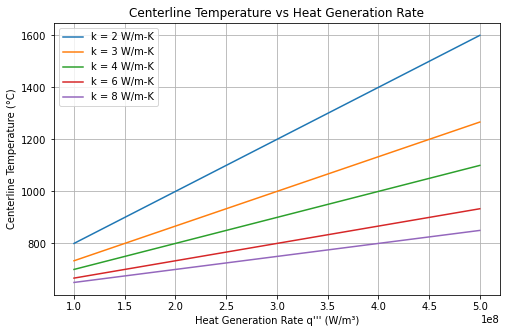

In [17]:
#T_center vs Heat Generation rate for differents Materials

# Parameters
R = 0.004      # m
Ts = 600       # °C

# Thermal conductivities
mat = [2, 3, 4, 6, 8]

# Heat generation rates
powers = np.linspace(1e8, 5e8, 50)

plt.figure(figsize=(8,5))

for k in mat:

    # T_center para TODOS los valores de potencia
    T_center = Ts + powers * R**2 / (4*k)

    # Ajuste lineal
    coeffs = np.polyfit(powers, T_center, 1)

    slope = coeffs[0]
    intercept = coeffs[1]

    print(f"\nk = {k} W/m-K")
    print(f"T_center = {slope:.3e} * q''' + {intercept:.2f}")

    # Graficar
    plt.plot(
        powers,
        T_center,
        label=f"k = {k} W/m-K"
    )

plt.xlabel("Heat Generation Rate q''' (W/m³)")
plt.ylabel("Centerline Temperature (°C)")
plt.title("Centerline Temperature vs Heat Generation Rate")
plt.legend()
plt.grid(True)
plt.savefig("center_temperature.png",dpi=300,bbox_inches="tight")
plt.show()

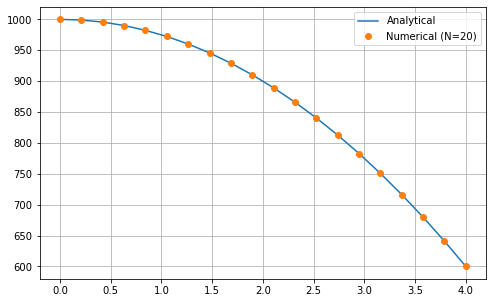

Error ∝ N^(1.5103)
Order of convergence p = -1.5103


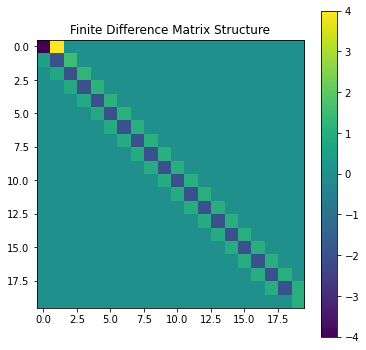

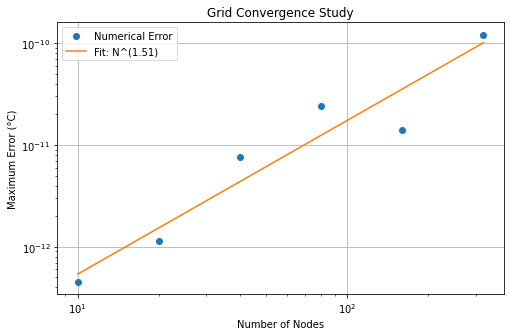

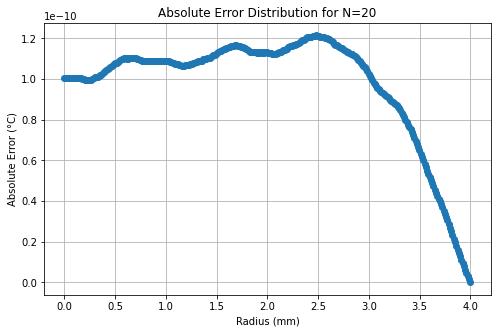

In [24]:
import numpy as np
import matplotlib.pyplot as plt
#Queremos resolver d²T/dr² = -q'''/k en 0<r<R con dT/dr = 0 en r=0 y T = Ts en r=R.
R = 0.004      # m
Ts = 600       # °C
k = 3          # W/m-K
q = 3e8        # W/m³

#Construyo malla
N_values = [10,20,40,80,160,320]
#N = 16

errors=[]
for N in N_values:
    r = np.linspace(0, R, N)

    dr = r[1] - r[0]
    
#Armo matriz A*T=b
    A = np.zeros((N,N))
    b = np.zeros(N)

    for i in range(1, N-1):

        A[i,i-1] = 1 - dr/(2*r[i])
        A[i,i]   = -2
        A[i,i+1] = 1 + dr/(2*r[i])

        b[i] = -(q/k)*dr**2
    
#Condiciones de borde

#4T1-4T0=-(q/k)*dr**2  simetria en el centro T-1=T1

    A[0,0] = -4
    A[0,1] = 4

    b[0] = -(q/k)*dr**2 

#TN-1=Ts T en la superficie 

    A[-1,-1] = 1
    b[-1] = Ts

#print(A) print(b)


    T_numeric = np.linalg.solve(A,b)
    T_analytic = Ts + q/(4*k)*(R**2-r**2)
    error_max = np.max(np.abs(T_numeric - T_analytic))
    errors.append(error_max)
    
    if N == 20:
        plt.figure(figsize=(8,5))
        plt.plot(r*1000, T_analytic, label="Analytical")
        plt.plot(r*1000, T_numeric, "o", label=f"Numerical (N={N})")
        plt.legend()
        plt.grid()
        plt.savefig("temperature_profile.png", dpi=300, bbox_inches="tight")
        plt.show()
        plt.figure(figsize=(6,6))
        plt.imshow(A)
        plt.colorbar()
        plt.title("Finite Difference Matrix Structure")

        plt.savefig("matrix_structure.png", dpi=300, bbox_inches="tight")
coeffs = np.polyfit(np.log(N_values),np.log(errors),1)
slope = coeffs[0]

print(f"Error ∝ N^({slope:.4f})")
print(f"Order of convergence p = {-slope:.4f}")

N_fit = np.logspace(np.log10(min(N_values)),np.log10(max(N_values)),200)

error_fit = np.exp(coeffs[1]) * N_fit**coeffs[0]

plt.figure(figsize=(8,5))

plt.loglog(N_values,errors,"o",label="Numerical Error")

plt.loglog(N_fit,error_fit,label=f"Fit: N^({slope:.2f})")

plt.xlabel("Number of Nodes")
plt.ylabel("Maximum Error (°C)")
plt.title("Grid Convergence Study")
plt.legend()
plt.grid(True)

plt.show()
error = np.abs(T_numeric - T_analytic)

plt.figure(figsize=(8,5))
plt.plot(r*1000, error, "o-")
plt.xlabel("Radius (mm)")
plt.ylabel("Absolute Error (°C)")
plt.title("Absolute Error Distribution for N=20")
plt.grid(True)

plt.savefig("error_distribution.png", dpi=300, bbox_inches="tight")
plt.show()